# Model Comparison

Goal of this notebook: pick a single best regressor that we will fine-tune in notebook 04. We train seven candidates on the engineered features, run 3-fold cross-validation on each, and rank them by test RMSE.

## Why these seven models?

We cover the main regression families so that whichever wins gives us a clear signal about the structure of the data:

| Family | Models | What it tells us if it wins |
|---|---|---|
| Linear (no regularization) | LinearRegression | The relationship is mostly linear in the engineered features. |
| Linear (regularized) | Ridge, Lasso | Same as above but with shrinkage helping against overfit / collinearity. |
| Instance-based | KNN | Local patterns dominate. |
| Tree ensemble (bagging) | RandomForest | Non-linear interactions matter. |
| Tree ensemble (boosting) | GradientBoosting, XGBoost | Sequential boosting captures stronger non-linearities. |

## Why not SVR?

RBF SVR is O(n^2) on roughly 28k training rows, so it dominates total runtime. On smaller subsamples it lands at the same RMSE as the linear models on this dataset, so we excluded it for time.

## Imports

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
PROC_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load processed splits

In [2]:
X_train = pd.read_csv(PROC_DIR / 'X_train_filtered.csv')
X_test = pd.read_csv(PROC_DIR / 'X_test_filtered.csv')
y_train = pd.read_csv(PROC_DIR / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(PROC_DIR / 'y_test.csv').squeeze('columns')
preprocessor = joblib.load(MODEL_DIR / 'preprocessor.joblib')
print(f'Train {X_train.shape}, Test {X_test.shape}')

Train (28800, 61), Test (7200, 61)


## Define candidates

In [3]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    'KNN': KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE),
}
try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,
                                     subsample=0.9, colsample_bytree=0.9,
                                     random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
                                     objective='reg:squarederror')
except Exception as exc:
    print('XGBoost not available:', exc)
print(f'Total candidates: {len(models)}')

Total candidates: 7


## Train, evaluate, cross-validate

For each model we run a Pipeline `[preprocessor -> model]` so all models see exactly the same input transformation. We score on the held-out test set, then run 3-fold CV on the training set as a separate stability check.

In [4]:
results = []
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mae = float(mean_absolute_error(y_test, pred))
    r2 = float(r2_score(y_test, pred))
    cv_rmse = float(-cross_val_score(pipe, X_train, y_train, cv=3,
                                     scoring='neg_root_mean_squared_error', n_jobs=-1).mean())
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_RMSE': cv_rmse})
    joblib.dump(pipe, MODEL_DIR / f'{name}.joblib')
    print(f'{name:18s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  CV_RMSE={cv_rmse:.4f}')

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.to_csv(MODEL_DIR / 'model_results.csv', index=False)
results_df.round(4)

LinearRegression    RMSE=0.9145  MAE=0.7207  R2=0.8404  CV_RMSE=0.9268


Ridge               RMSE=0.9145  MAE=0.7207  R2=0.8404  CV_RMSE=0.9268


Lasso               RMSE=0.9204  MAE=0.7254  R2=0.8383  CV_RMSE=0.9358


KNN                 RMSE=1.2157  MAE=0.9688  R2=0.7180  CV_RMSE=1.2384


RandomForest        RMSE=1.0044  MAE=0.7937  R2=0.8075  CV_RMSE=1.0246


GradientBoosting    RMSE=0.8809  MAE=0.6888  R2=0.8519  CV_RMSE=0.8958


XGBoost             RMSE=0.8712  MAE=0.6813  R2=0.8552  CV_RMSE=0.8864


,Model,RMSE,MAE,R2,CV_RMSE
0,XGBoost,0.8712,0.6813,0.8552,0.8864
1,GradientBoosting,0.8809,0.6888,0.8519,0.8958
2,Ridge,0.9145,0.7207,0.8404,0.9268
3,LinearRegression,0.9145,0.7207,0.8404,0.9268
4,Lasso,0.9204,0.7254,0.8383,0.9358
5,RandomForest,1.0044,0.7937,0.8075,1.0246
6,KNN,1.2157,0.9688,0.7180,1.2384


## Visual ranking

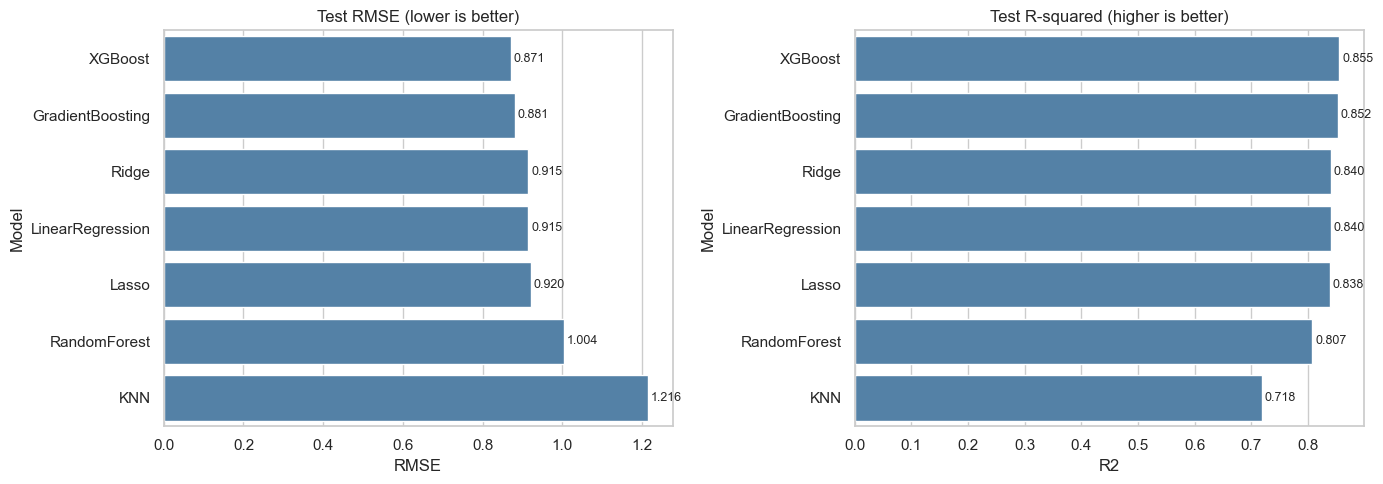

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df.sort_values('RMSE'), x='RMSE', y='Model', color='steelblue', ax=axes[0])
axes[0].set_title('Test RMSE (lower is better)')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=2, fontsize=9)
sns.barplot(data=results_df.sort_values('R2', ascending=False), x='R2', y='Model', color='steelblue', ax=axes[1])
axes[1].set_title('Test R-squared (higher is better)')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Test vs cross-validation: is the ranking stable?

If a model has a much lower test RMSE than its CV RMSE, it might be lucky on the held-out split. We want the winner to be at the top of both.

In [6]:
stability = results_df[['Model', 'RMSE', 'CV_RMSE']].copy()
stability['gap'] = (stability['CV_RMSE'] - stability['RMSE']).round(4)
stability.sort_values('RMSE')

,Model,RMSE,CV_RMSE,gap
0,XGBoost,0.871171,0.886422,0.0153
1,GradientBoosting,0.880937,0.895755,0.0148
2,Ridge,0.914511,0.926754,0.0122
3,LinearRegression,0.914522,0.926754,0.0122
4,Lasso,0.920446,0.935761,0.0153
5,RandomForest,1.004437,1.024633,0.0202
6,KNN,1.215742,1.238394,0.0227


## Picking the winner

We use Linear Regression as a sanity baseline. The winner has to clearly beat it on RMSE before we commit to fine-tuning.

In [7]:
best_row = results_df.sort_values(['R2', 'RMSE'], ascending=[False, True]).iloc[0]
best_name = best_row['Model']
runner_up = results_df.sort_values('RMSE').iloc[1]
lin_row = results_df[results_df['Model'] == 'LinearRegression'].iloc[0]

rmse_gain_pct = (lin_row['RMSE'] - best_row['RMSE']) / lin_row['RMSE'] * 100
r2_gain = best_row['R2'] - lin_row['R2']
ru_gap_pct = (runner_up['RMSE'] - best_row['RMSE']) / runner_up['RMSE'] * 100

print(f'Linear Regression baseline : RMSE={lin_row["RMSE"]:.4f}  R2={lin_row["R2"]:.4f}')
print(f'Runner up ({runner_up["Model"]:>16s}): RMSE={runner_up["RMSE"]:.4f}  R2={runner_up["R2"]:.4f}')
print(f'Winner    ({best_name:>16s}): RMSE={best_row["RMSE"]:.4f}  R2={best_row["R2"]:.4f}')
print()
print(f'Winner vs Linear baseline: RMSE -{rmse_gain_pct:.1f}%, R2 +{r2_gain:.4f}')
print(f'Winner vs runner-up      : RMSE -{ru_gap_pct:.2f}%')

joblib.dump({'best_name': best_name}, MODEL_DIR / 'best_name.joblib')
print()
print(f'Saved best_name.joblib. Notebook 04 will fine-tune {best_name}.')

Linear Regression baseline : RMSE=0.9145  R2=0.8404
Runner up (GradientBoosting): RMSE=0.8809  R2=0.8519
Winner    (         XGBoost): RMSE=0.8712  R2=0.8552

Winner vs Linear baseline: RMSE -4.7%, R2 +0.0148
Winner vs runner-up      : RMSE -1.11%

Saved best_name.joblib. Notebook 04 will fine-tune XGBoost.
